In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.datasets import fashion_mnist

In [4]:
(train_images, train_labels) , (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(type(train_images))

<class 'numpy.ndarray'>


In [6]:
print(train_images.ndim)

3


In [7]:
print(train_images.shape)

(60000, 28, 28)


In [8]:
print(train_labels.shape)

(60000,)


In [9]:
print(test_labels.shape)

(10000,)


In [10]:
print(train_labels)

[9 0 0 ... 3 0 5]


In [11]:
print(test_labels)

[9 2 1 ... 8 1 5]


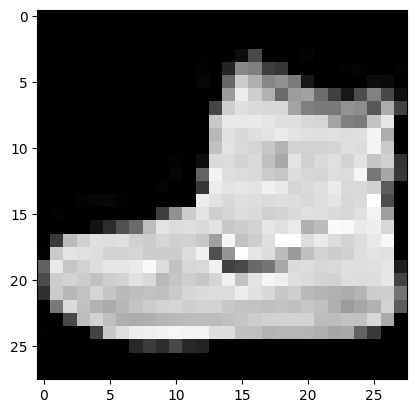

In [12]:
plt.imshow(train_images[0], cmap="gray")

In [13]:
print(train_labels[0])

9


In [15]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [16]:
print(class_names[train_labels[0]])

Ankle boot


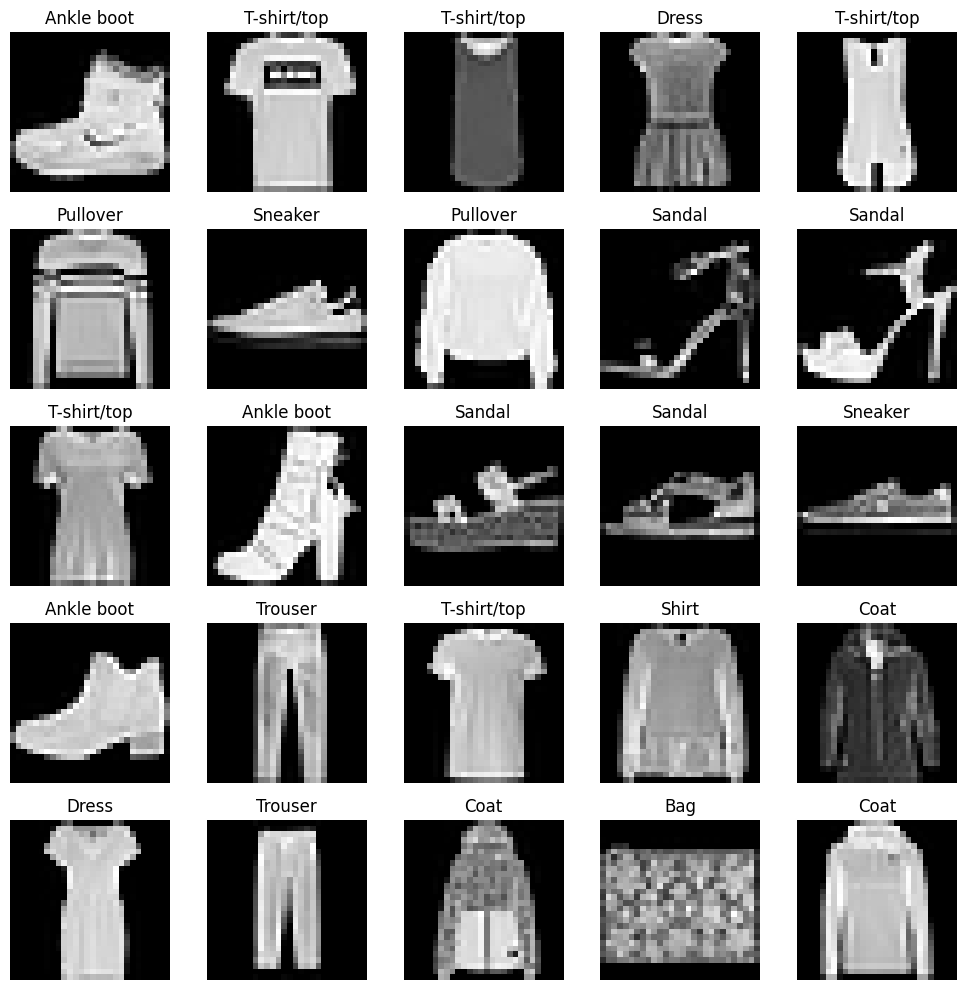

In [17]:
plt.figure(figsize=(10,10))
for i in range(25):
  plt.subplot(5,5, i+1)
  plt.imshow(train_images[i], cmap='gray')
  plt.title(class_names[train_labels[i]])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [18]:
print(train_images[0])
print(train_images[0].min())
print(train_images[0].max())


[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

In [19]:
from tensorflow.keras.utils import to_categorical
encoded_train_labels = to_categorical(train_labels)
encoded_test_labels = to_categorical(test_labels)
print(encoded_train_labels.shape)
print(encoded_test_labels.shape)

(60000, 10)
(10000, 10)


In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [23]:
model = Sequential([

            Dense(512, activation='relu'),

            Dense(10, activation='softmax'),

])

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(

    optimizer="adam",
    # Adam optimizer model ke weights ko update karta hai

    loss="sparse_categorical_crossentropy",
    # Classification problem ke liye loss function use kar rahe hain

    metrics=["accuracy"]
    # Training ke waqt accuracy calculate kar rahe hain
)



In [26]:

print(train_images.shape)  # Images ka original shape check kar rahe hain

print(test_images.shape)  # Test images ka original shape check kar rahe hain

(60000, 28, 28)
(10000, 28, 28)


In [27]:
train_images = train_images.reshape((60000, 784))
# 60000 images hain
# Har image 28 x 28 pixels ki hai
# 28 x 28 = 784
# Isliye har image ko 784 pixels ki single row mein convert kar rahe hain

In [28]:
test_images = test_images.reshape((10000, 784))
# 10000 testing images ko bhi 784 pixels ki single row mein convert kar rahe hain

In [29]:
train_images = train_images.astype("float32")
# Training images ke pixel values ko float32 data type mein convert kar rahe hain

test_images = test_images.astype("float32")
# Testing images ke pixel values ko float32 data type mein convert kar rahe hain

In [30]:
train_images = train_images / 255
# Pixel values normally 0 se 255 ke darmiyan hoti hain
# 255 se divide karke values ko 0 se 1 ke range mein la rahe hain

test_images = test_images / 255
# Testing images ke pixel values ko bhi 0 se 1 ke range mein normalize kar rahe hain

In [31]:
print(train_images.shape)  # Reshape ke baad training data ka shape check kar rahe hain

print(test_images.shape)  # Reshape ke baad testing data ka shape check kar rahe hain

(60000, 784)
(10000, 784)


In [32]:
history = model.fit(

    train_images,
    # Training images model ko provide kar rahe hain

    train_labels,
    # Original numerical labels model ko provide kar rahe hain

    epochs=20,
    # Model ko complete training dataset 20 times train karwa rahe hain

    batch_size=128,
    # Har step mein 128 images process hongi

    validation_split=0.1
    # Training data ka 10% validation ke liye use kar rahe hain
)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8243 - loss: 0.5082 - val_accuracy: 0.8588 - val_loss: 0.3980
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8666 - loss: 0.3803 - val_accuracy: 0.8697 - val_loss: 0.3679
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8785 - loss: 0.3381 - val_accuracy: 0.8723 - val_loss: 0.3461
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8866 - loss: 0.3127 - val_accuracy: 0.8800 - val_loss: 0.3311
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8932 - loss: 0.2920 - val_accuracy: 0.8878 - val_loss: 0.3119
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8996 - loss: 0.2747 - val_accuracy: 0.8862 - val_loss: 0.3201
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9030 - loss: 0.2615 - val_accuracy: 0.8875 - val_loss: 0.3154
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9090 - loss: 0.2490 - val_acc

In [33]:
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels
)
# Testing images aur labels ke against trained model ko evaluate kar rahe hain

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8894 - loss: 0.3430


In [34]:
print("Test Loss:", test_loss)  # Test loss display kar rahe hain

print("Test Accuracy:", test_accuracy)  # Test accuracy display kar rahe hain

Test Loss: 0.3429809808731079
Test Accuracy: 0.8894000053405762


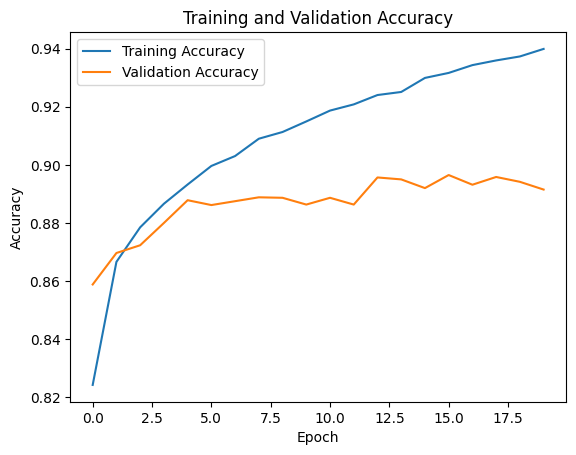

In [35]:
plt.plot(history.history["accuracy"])
# Har epoch ki training accuracy ka graph bana rahe hain

plt.plot(history.history["val_accuracy"])
# Har epoch ki validation accuracy ka graph bana rahe hain

plt.title("Training and Validation Accuracy")
# Graph ka title set kar rahe hain

plt.xlabel("Epoch")
# X-axis ko Epoch ka naam de rahe hain

plt.ylabel("Accuracy")
# Y-axis ko Accuracy ka naam de rahe hain

plt.legend(["Training Accuracy", "Validation Accuracy"])
# Dono lines ka legend show kar rahe hain

plt.show()
# Accuracy graph display kar rahe hain

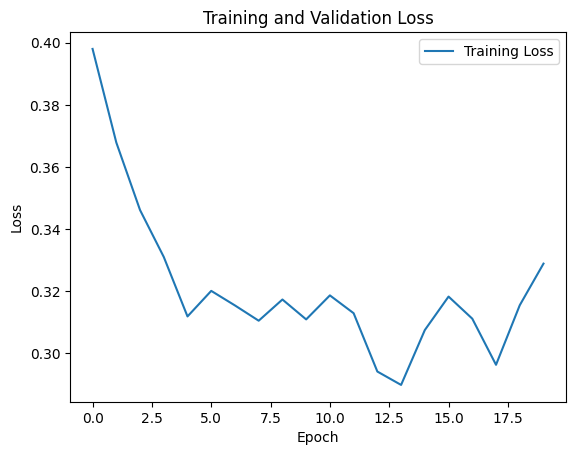

In [36]:

plt.plot(history.history["val_loss"])
# Har epoch ki validation loss ka graph bana rahe hain

plt.title("Training and Validation Loss")
# Graph ka title set kar rahe hain

plt.xlabel("Epoch")
# X-axis ka naam Epoch set kar rahe hain

plt.ylabel("Loss")
# Y-axis ka naam Loss set kar rahe hain

plt.legend(["Training Loss", "Validation Loss"])
# Training aur validation loss ka legend show kar rahe hain

plt.show()
# Loss graph display kar rahe hain

In [37]:
predictions = model.predict(test_images)
# Test images par model predictions generate kar raha hai

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [38]:
predicted_labels = np.argmax(predictions, axis=1)
# Har image ke liye jis class ki probability sabse zyada hai
# us class ka numerical label select kar rahe hain

In [39]:
print("Predicted Label:", predicted_labels[0])
# Pehli test image ka predicted numerical label display kar rahe hain

print("Predicted Class:", class_names[predicted_labels[0]])
# Predicted numerical label ko clothing class name mein convert kar rahe hain

print("Actual Label:", test_labels[0])
# Pehli test image ka actual numerical label display kar rahe hain

print("Actual Class:", class_names[test_labels[0]])
# Actual numerical label ko clothing class name mein convert kar rahe hain

Predicted Label: 9
Predicted Class: Ankle boot
Actual Label: 9
Actual Class: Ankle boot


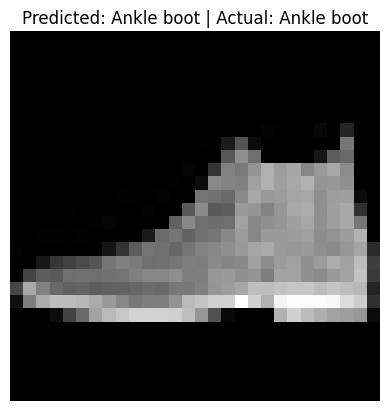

In [40]:
plt.imshow(test_images[0].reshape(28, 28), cmap="gray")
# Flattened image ko dobara 28 x 28 shape mein convert karke display kar rahe hain

plt.title(
    "Predicted: " + class_names[predicted_labels[0]] +
    " | Actual: " + class_names[test_labels[0]]
)
# Image ke upar predicted aur actual class dono show kar rahe hain

plt.axis("off")
# Image ke axes hide kar rahe hain

plt.show()
# Image display kar rahe hain

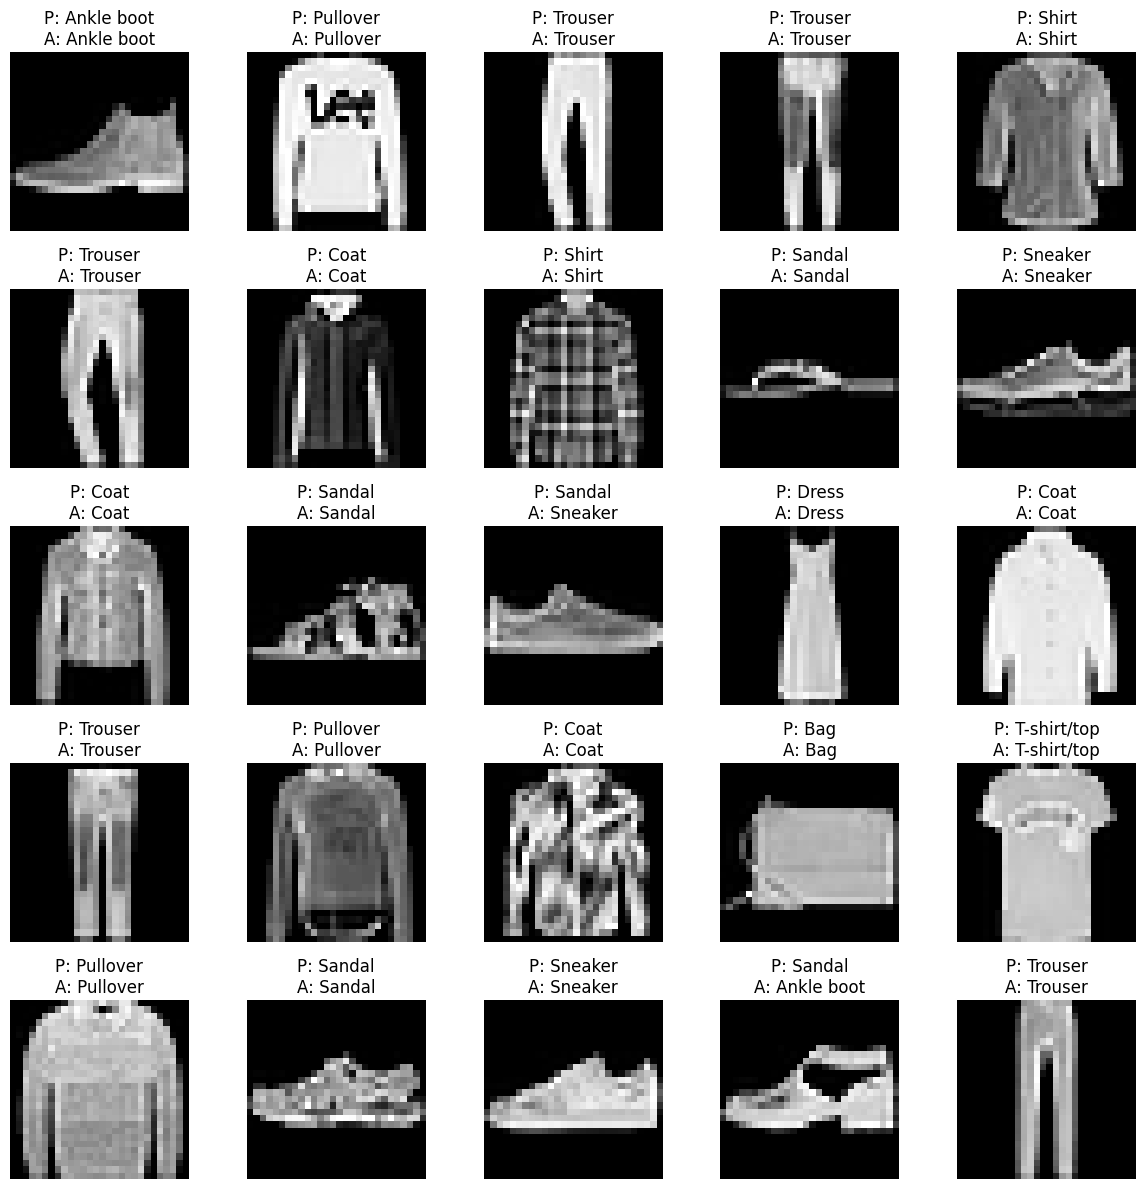

In [41]:
plt.figure(figsize=(12, 12))
# Multiple prediction images ke liye figure size set kar rahe hain

for i in range(25):
    # Pehli 25 test images ke liye loop chala rahe hain

    plt.subplot(5, 5, i + 1)
    # 5 x 5 image grid create kar rahe hain

    plt.imshow(test_images[i].reshape(28, 28), cmap="gray")
    # Flattened image ko 28 x 28 mein convert karke display kar rahe hain

    plt.title(
        "P: " + class_names[predicted_labels[i]] +
        "\nA: " + class_names[test_labels[i]]
    )
    # P = predicted class
    # A = actual class

    plt.axis("off")
    # Axes hide kar rahe hain

plt.tight_layout()
# Images ki spacing adjust kar rahe hain

plt.show()
# Complete prediction grid display kar rahe hain

In [42]:
from sklearn.metrics import confusion_matrix
# Confusion matrix calculate karne ke liye function import kar rahe hain

cm = confusion_matrix(test_labels, predicted_labels)
# Actual labels aur predicted labels ko compare karke confusion matrix bana rahe hain

print(cm)
# Confusion matrix ko numerical form mein display kar rahe hain

[[863   0   7  19   4   1  93   0  13   0]
 [  3 975   0  16   3   0   2   0   1   0]
 [ 16   0 773  15  66   0 129   0   1   0]
 [ 27   1  11 922  18   0  14   0   7   0]
 [  0   0  95  45 744   0 107   0   9   0]
 [  0   0   0   1   0 968   0  22   1   8]
 [128   1  43  31  34   0 751   0  12   0]
 [  0   0   0   0   0   9   0 972   0  19]
 [  5   0   4   0   0   1   6   5 979   0]
 [  0   0   0   0   0   9   1  43   0 947]]


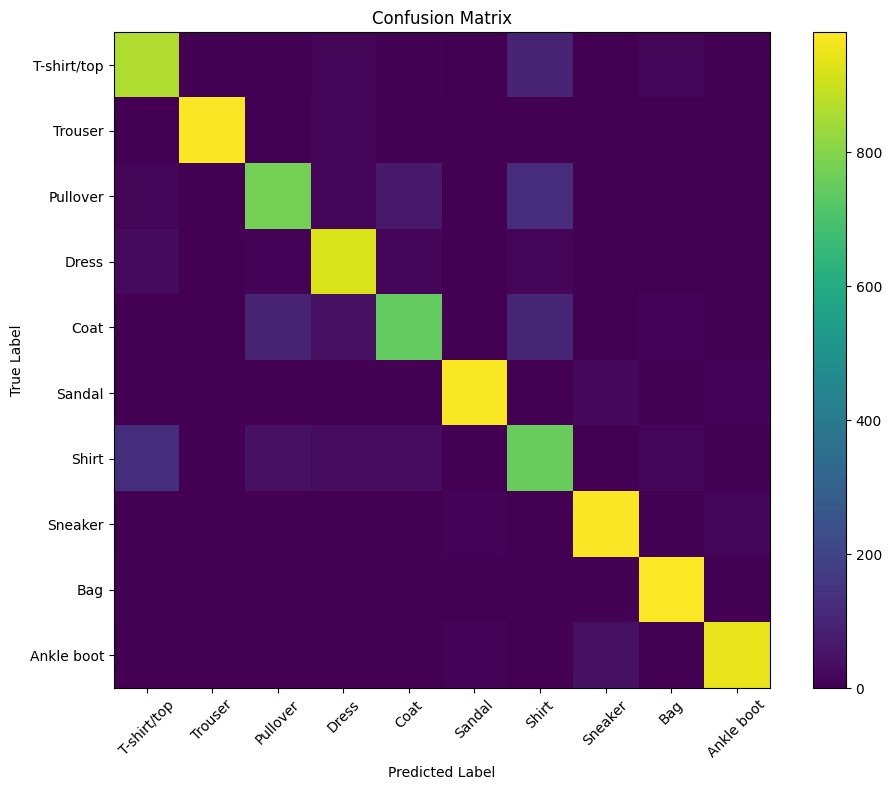

In [43]:
plt.figure(figsize=(10, 8))
# Confusion matrix ke graph ka size set kar rahe hain

plt.imshow(cm)
# Confusion matrix ko image ki form mein display kar rahe hain

plt.title("Confusion Matrix")
# Graph ka title set kar rahe hain

plt.xlabel("Predicted Label")
# X-axis par predicted labels show kar rahe hain

plt.ylabel("True Label")
# Y-axis par actual/true labels show kar rahe hain

plt.xticks(range(10), class_names, rotation=45)
# X-axis par 10 clothing classes ke names show kar rahe hain

plt.yticks(range(10), class_names)
# Y-axis par 10 clothing classes ke names show kar rahe hain

plt.colorbar()
# Confusion matrix ke values ka color scale show kar rahe hain

plt.tight_layout()
# Graph ki spacing adjust kar rahe hain

plt.show()
# Confusion matrix display kar rahe hain

In [44]:
model.save("fashion_mnist_model.keras")
# Trained Fashion-MNIST model ko file mein save kar rahe hain

In [47]:
from tensorflow import keras
loaded_model = keras.models.load_model("fashion_mnist_model.keras")
# Saved model ko dobara load kar rahe hain


In [48]:
loaded_model.summary()
# Loaded model ki architecture dobara display kar rahe hain

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,221,152 (4.66 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 814,102 (3.11 MB)

In [49]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(
    test_images,
    test_labels
)
# Loaded model ko test dataset par evaluate kar rahe hain

print("Loaded Model Accuracy:", loaded_accuracy)
# Loaded model ki test accuracy display kar rahe hain

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8894 - loss: 0.3430
Loaded Model Accuracy: 0.8894000053405762


In [50]:
sample_index = 10
# Testing dataset mein se image number 10 select kar rahe hain

sample_image = test_images[sample_index]
# Selected image ko variable mein store kar rahe hain

sample_prediction = loaded_model.predict(
    np.expand_dims(sample_image, axis=0)
)
# Selected image ko model mein prediction ke liye bhej rahe hain
# expand_dims image ko batch format mein convert karta hai

sample_label = np.argmax(sample_prediction)
# Sabse high probability wali class ka numerical label nikal rahe hain

print("Predicted:", class_names[sample_label])
# Predicted clothing class ka naam display kar rahe hain

print("Actual:", class_names[test_labels[sample_index]])
# Actual clothing class ka naam display kar rahe hain

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
Predicted: Coat
Actual: Coat


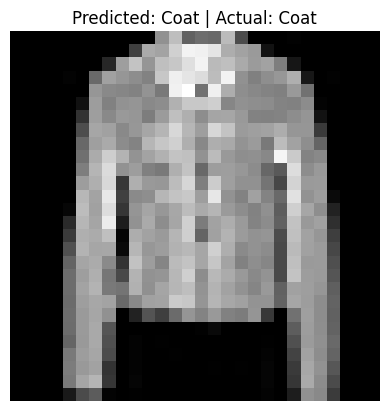

In [51]:
plt.imshow(sample_image.reshape(28, 28), cmap="gray")
# Selected flattened image ko dobara 28 x 28 mein convert karke display kar rahe hain

plt.title(
    "Predicted: " + class_names[sample_label] +
    " | Actual: " + class_names[test_labels[sample_index]]
)
# Predicted aur actual class image ke title mein display kar rahe hain

plt.axis("off")
# Image ke axes hide kar rahe hain

plt.show()
# Final prediction image display kar rahe hain